Moments of Inertia (kg*m^2): I_xx=0.0333, I_yy=0.0333, I_zz=0.0067


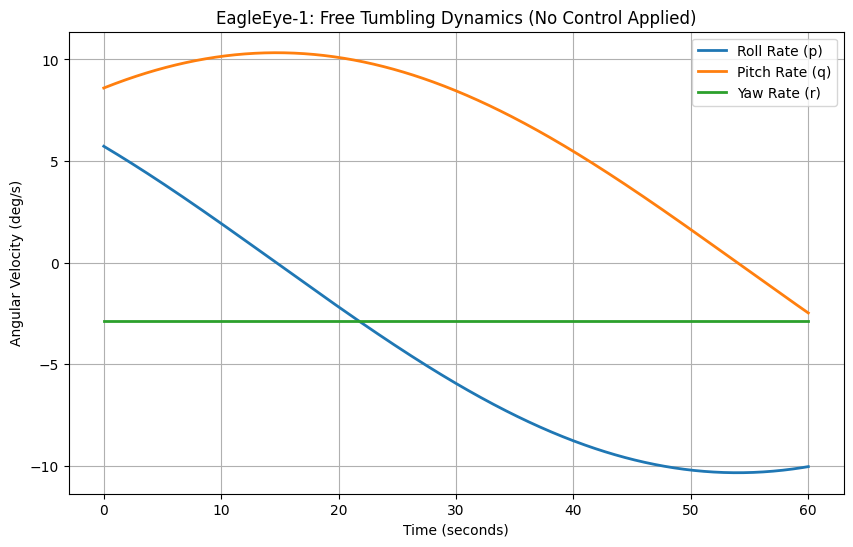

In [1]:
# ADCS: Rigid Body Dynamics Simulation
# EagleEye-1 Mission - Free Tumbling Analysis

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 1. CUBESAT 3U PROPERTIES [REQ-SYS-010, REQ-SYS-020]
mass_kg = 4.0
width_m = 0.10  # x-axis
depth_m = 0.10  # y-axis
height_m = 0.30 # z-axis

# 2. INERTIA TENSOR (Assuming uniform mass distribution for now)
# I = 1/12 * m * (a^2 + b^2)
I_xx = (1.0/12.0) * mass_kg * (depth_m**2 + height_m**2)
I_yy = (1.0/12.0) * mass_kg * (width_m**2 + height_m**2)
I_zz = (1.0/12.0) * mass_kg * (width_m**2 + depth_m**2)

I = np.array([I_xx, I_yy, I_zz])
print(f"Moments of Inertia (kg*m^2): I_xx={I_xx:.4f}, I_yy={I_yy:.4f}, I_zz={I_zz:.4f}")

# 3. EULER'S EQUATIONS OF MOTION
def rigid_body_dynamics(t, omega, I, torque):
    """
    Computes the angular acceleration (d_omega/dt) using Euler's equations.
    omega: [p, q, r] (angular velocities in body frame rad/s)
    """
    p, q, r = omega
    I_x, I_y, I_z = I
    tau_x, tau_y, tau_z = torque
    
    # Differential equations for angular velocities
    dp_dt = (tau_x - (I_z - I_y) * q * r) / I_x
    dq_dt = (tau_y - (I_x - I_z) * p * r) / I_y
    dr_dt = (tau_z - (I_y - I_x) * p * q) / I_z
    
    return [dp_dt, dq_dt, dr_dt]

# 4. SIMULATION SETUP
# Initial angular velocity: tumbling after deployment (~5-8 deg/s)
omega_0 = [0.10, 0.15, -0.05] # rad/s
t_span = (0, 60) # Simulate the first 60 seconds
t_eval = np.linspace(t_span[0], t_span[1], 500)

# External torques (0 for free tumbling in a vacuum)
applied_torque = [0.0, 0.0, 0.0]

# 5. SOLVE DIFFERENTIAL EQUATIONS
sol = solve_ivp(rigid_body_dynamics, t_span, omega_0, args=(I, applied_torque), t_eval=t_eval)

# 6. VISUALIZATION
plt.figure(figsize=(10, 6))
# Convert rad/s to deg/s for easier reading
plt.plot(sol.t, sol.y[0] * (180/np.pi), label='Roll Rate (p)', linewidth=2)
plt.plot(sol.t, sol.y[1] * (180/np.pi), label='Pitch Rate (q)', linewidth=2)
plt.plot(sol.t, sol.y[2] * (180/np.pi), label='Yaw Rate (r)', linewidth=2)

plt.title('EagleEye-1: Free Tumbling Dynamics (No Control Applied)')
plt.xlabel('Time (seconds)')
plt.ylabel('Angular Velocity (deg/s)')
plt.grid(True)
plt.legend()
plt.show()

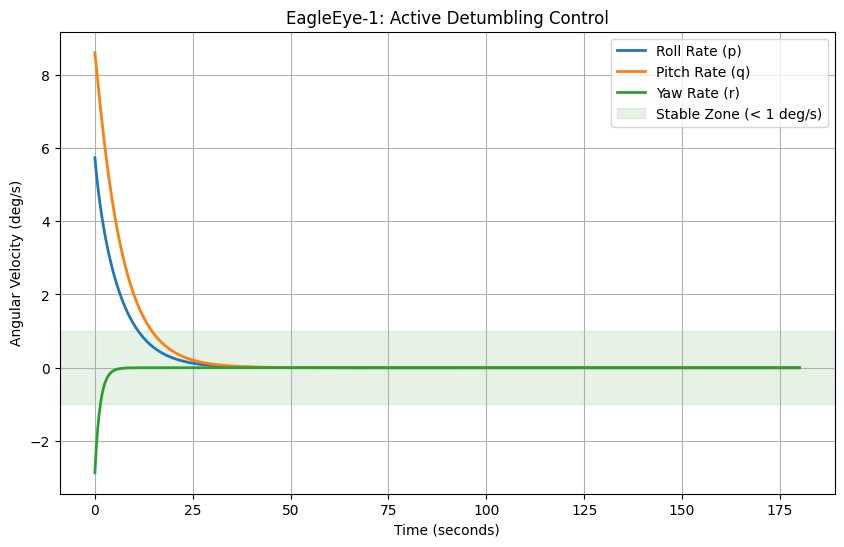

In [2]:
# ADCS: Active Detumbling Control (Rate Damping)
# EagleEye-1 Mission

# 1. CONTROL PARAMETERS
# k_gain: Controller aggressiveness (Nm / (rad/s))
k_gain = 0.005 

# Max torque limit (Realism: Actuators have physical limits. A typical 3U magnetorquer yields ~2-5 mNm)
MAX_TORQUE_NM = 0.003 

def controlled_dynamics(t, omega, I, k, max_tau):
    """
    Computes angular acceleration including active braking control.
    """
    p, q, r = omega
    I_x, I_y, I_z = I
    
    # A. SENSOR READING (Assuming perfect gyroscopes for now)
    current_omega = np.array([p, q, r])
    
    # B. CONTROL LAW (Tau = -K * omega)
    tau_ctrl = -k * current_omega
    
    # C. ACTUATOR SATURATION (Apply physical limits)
    tau_ctrl = np.clip(tau_ctrl, -max_tau, max_tau)
    tau_x, tau_y, tau_z = tau_ctrl
    
    # D. ROTATIONAL DYNAMICS (Euler's equations with applied torque)
    dp_dt = (tau_x - (I_z - I_y) * q * r) / I_x
    dq_dt = (tau_y - (I_x - I_z) * p * r) / I_y
    dr_dt = (tau_z - (I_y - I_x) * p * q) / I_z
    
    return [dp_dt, dq_dt, dr_dt]

# 2. RUN SIMULATION
t_span_ctrl = (0, 180) # Let's simulate 3 minutes (180 seconds)
t_eval_ctrl = np.linspace(t_span_ctrl[0], t_span_ctrl[1], 1000)

sol_ctrl = solve_ivp(
    controlled_dynamics, 
    t_span_ctrl, 
    omega_0, # Re-using initial tumbling from previous cell
    args=(I, k_gain, MAX_TORQUE_NM), 
    t_eval=t_eval_ctrl
)

# 3. VISUALIZATION
plt.figure(figsize=(10, 6))
plt.plot(sol_ctrl.t, sol_ctrl.y[0] * (180/np.pi), label='Roll Rate (p)', linewidth=2)
plt.plot(sol_ctrl.t, sol_ctrl.y[1] * (180/np.pi), label='Pitch Rate (q)', linewidth=2)
plt.plot(sol_ctrl.t, sol_ctrl.y[2] * (180/np.pi), label='Yaw Rate (r)', linewidth=2)

# Add a threshold box to show when the satellite is considered "stable" (< 1 deg/s)
plt.axhspan(-1, 1, color='green', alpha=0.1, label='Stable Zone (< 1 deg/s)')

plt.title('EagleEye-1: Active Detumbling Control')
plt.xlabel('Time (seconds)')
plt.ylabel('Angular Velocity (deg/s)')
plt.grid(True)
plt.legend()
plt.show()

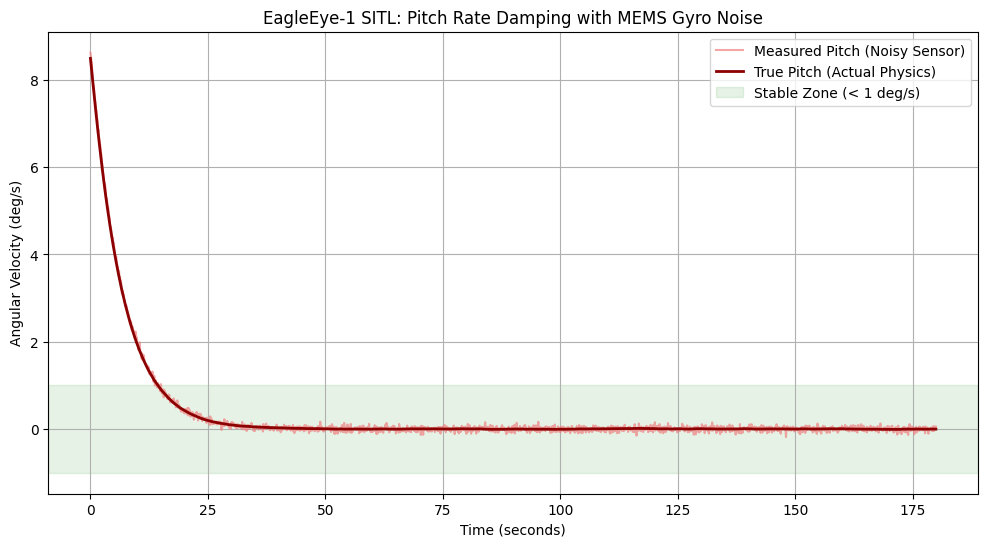

In [3]:
# ADCS: Software-in-the-Loop (SITL) Simulation
# EagleEye-1 Mission - Discrete Control with Sensor Noise

import numpy as np
import matplotlib.pyplot as plt

# 1. HARDWARE SPECIFICATIONS
k_gain = 0.005 
MAX_TORQUE_NM = 0.003
OBC_FREQUENCY_HZ = 10.0  # Flight computer runs at 10 Hz
dt = 1.0 / OBC_FREQUENCY_HZ

# Sensor noise profile (MEMS Gyroscope: ~0.05 deg/s standard deviation)
NOISE_STD_DEV_DEG = 0.05 
noise_std_dev_rad = NOISE_STD_DEV_DEG * (np.pi / 180.0)

# 2. INITIALIZATION
t_sim = 180.0 # Simulate 3 minutes
steps = int(t_sim / dt)

time_log = np.zeros(steps)
omega_true_log = np.zeros((steps, 3))
omega_measured_log = np.zeros((steps, 3))
torque_log = np.zeros((steps, 3))

# Initial tumbling state (rad/s)
omega_current = np.array([0.10, 0.15, -0.05])
I_tensor = np.array([I_xx, I_yy, I_zz]) # Re-using from cell 1

# 3. DISCRETE SIMULATION LOOP (The "Real" Flight Software)
for i in range(steps):
    # --- A. SENSOR MEASUREMENT (Add Gaussian Noise) ---
    noise = np.random.normal(0, noise_std_dev_rad, 3)
    omega_measured = omega_current + noise
    
    # --- B. FLIGHT COMPUTER LOGIC (Calculate Control Torque) ---
    tau_ctrl = -k_gain * omega_measured
    tau_commanded = np.clip(tau_ctrl, -MAX_TORQUE_NM, MAX_TORQUE_NM)
    
    # --- C. PHYSICS ENGINE (Euler Integration of Rigid Body) ---
    p, q, r = omega_current
    I_x, I_y, I_z = I_tensor
    tau_x, tau_y, tau_z = tau_commanded
    
    dp_dt = (tau_x - (I_z - I_y) * q * r) / I_x
    dq_dt = (tau_y - (I_x - I_z) * p * r) / I_y
    dr_dt = (tau_z - (I_y - I_x) * p * q) / I_z
    
    angular_accel = np.array([dp_dt, dq_dt, dr_dt])
    
    # Update real physics state for the next millisecond
    omega_current = omega_current + (angular_accel * dt)
    
    # Log data for telemetry
    time_log[i] = i * dt
    omega_true_log[i] = omega_current
    omega_measured_log[i] = omega_measured
    torque_log[i] = tau_commanded

# 4. VISUALIZATION: TRUE vs MEASURED RATE (Pitch Axis)
plt.figure(figsize=(12, 6))

plt.plot(time_log, omega_measured_log[:, 1] * (180/np.pi), 
         color='lightcoral', alpha=0.7, label='Measured Pitch (Noisy Sensor)')
plt.plot(time_log, omega_true_log[:, 1] * (180/np.pi), 
         color='darkred', linewidth=2, label='True Pitch (Actual Physics)')

plt.title('EagleEye-1 SITL: Pitch Rate Damping with MEMS Gyro Noise')
plt.xlabel('Time (seconds)')
plt.ylabel('Angular Velocity (deg/s)')
plt.axhspan(-1, 1, color='green', alpha=0.1, label='Stable Zone (< 1 deg/s)')
plt.grid(True)
plt.legend()
plt.show()

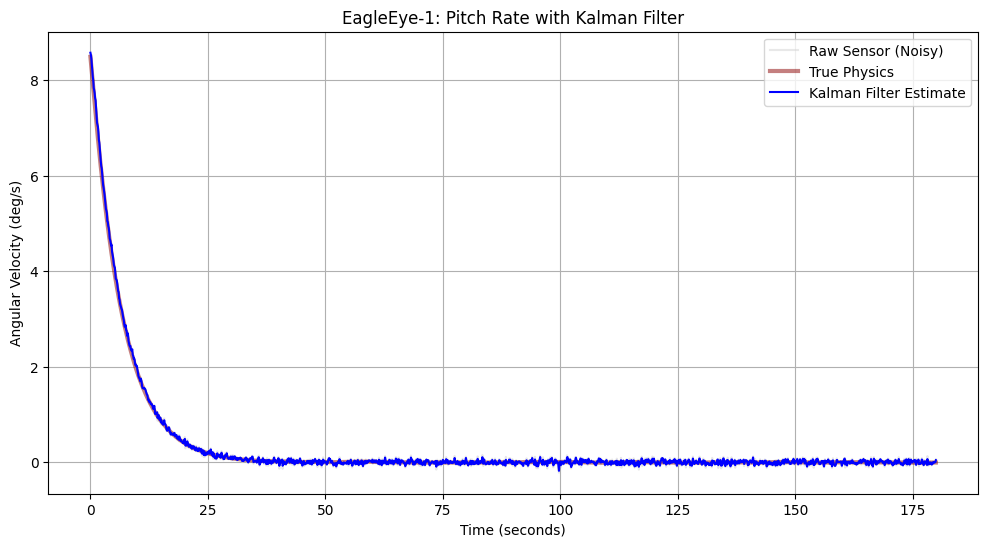

In [5]:
# ADCS: Software-in-the-Loop (SITL) with Kalman Filter (Matrix Fixed)
# EagleEye-1 Mission

import numpy as np
import matplotlib.pyplot as plt

# 1. HARDWARE & NOISE PARAMS
k_gain = 0.005 
MAX_TORQUE_NM = 0.003
dt = 0.1  # 10 Hz
NOISE_STD_DEV_DEG = 0.05 
noise_std_dev_rad = NOISE_STD_DEV_DEG * (np.pi / 180.0)

# 2. KALMAN FILTER INITIALIZATION
Q_kf = 1e-6 
R_kf = noise_std_dev_rad**2 
R_mat = R_kf * np.eye(3) # Matriz de ruido de medida 3x3

P_kf = np.eye(3) 
omega_estimate = np.array([0.10, 0.15, -0.05])

# 3. SIMULATION SETUP
t_sim = 180.0
steps = int(t_sim / dt)

time_log = np.zeros(steps)
omega_true_log = np.zeros((steps, 3))
omega_measured_log = np.zeros((steps, 3))
omega_estimate_log = np.zeros((steps, 3))

omega_current = np.array([0.10, 0.15, -0.05])
I_tensor = np.array([0.033, 0.033, 0.006]) 

# 4. DISCRETE SIMULATION LOOP
for i in range(steps):
    # --- A. TRUE PHYSICS ---
    noise = np.random.normal(0, noise_std_dev_rad, 3)
    omega_measured = omega_current + noise
    
    # --- B. KALMAN FILTER (Strict Matrix Algebra) ---
    # Step 1: Predict
    P_predict = P_kf + Q_kf * np.eye(3)
    
    # Step 2: Update ( K = P * (P + R)^-1 )
    S = P_predict + R_mat
    K_gain = P_predict @ np.linalg.inv(S)
    
    omega_estimate = omega_estimate + K_gain @ (omega_measured - omega_estimate)
    
    # Update covariance: P = (I - K) * P_predict
    P_kf = (np.eye(3) - K_gain) @ P_predict
    
    # --- C. CONTROL LAW ---
    tau_ctrl = -k_gain * omega_estimate
    tau_commanded = np.clip(tau_ctrl, -MAX_TORQUE_NM, MAX_TORQUE_NM)
    
    # --- D. PHYSICS ENGINE ---
    p, q, r = omega_current
    I_x, I_y, I_z = I_tensor
    tau_x, tau_y, tau_z = tau_commanded
    
    dp_dt = (tau_x - (I_z - I_y) * q * r) / I_x
    dq_dt = (tau_y - (I_x - I_z) * p * r) / I_y
    dr_dt = (tau_z - (I_y - I_x) * p * q) / I_z
    
    omega_current = omega_current + (np.array([dp_dt, dq_dt, dr_dt]) * dt)
    
    # Logging
    time_log[i] = i * dt
    omega_true_log[i] = omega_current
    omega_measured_log[i] = omega_measured
    omega_estimate_log[i] = omega_estimate

# 5. VISUALIZATION
plt.figure(figsize=(12, 6))

plt.plot(time_log, omega_measured_log[:, 1] * (180/np.pi), 
         color='lightgray', alpha=0.5, label='Raw Sensor (Noisy)')
plt.plot(time_log, omega_true_log[:, 1] * (180/np.pi), 
         color='darkred', linewidth=3, alpha=0.5, label='True Physics')
plt.plot(time_log, omega_estimate_log[:, 1] * (180/np.pi), 
         color='blue', linewidth=1.5, label='Kalman Filter Estimate')

plt.title('EagleEye-1: Pitch Rate with Kalman Filter')
plt.xlabel('Time (seconds)')
plt.ylabel('Angular Velocity (deg/s)')
plt.grid(True)
plt.legend()
plt.show()